In [22]:
os.listdir("/home/jovyan/work")

['notebooks', 'data']

In [33]:
import os
os.path.exists("/home/jovyan/work/data/spotify_songs.csv")

True

In [34]:
os.listdir("/home/jovyan/work/data")

['spotify_songs.csv']

# Introducción y Contexto

**Descripción del dataset**

El dataset utilizado en este análisis corresponde a Spotify Songs, obtenido desde la plataforma de datasets Kaggle.

Este conjunto de datos contiene 32,833 canciones y 23 variables relacionadas con características musicales, popularidad y metadatos de cada pista. Entre las variables importantes se incluyen:

* track_name: Nombre de la canción

* track_artist: Artista de la canción

* track_popularity: Nivel de popularidad de la canción en la plataforma

* Playlist_genre: género musical de la playlist

* Danceability: Qué tan bailable es una canción

* Energy: Nivel de intensidad o energía de la canción

* Tempo: Velocidad de la canción en beats por minuto

* Acousticness: Nivel de acústica de la canción


El dataset permite analizar cómo ciertas propiedades musicales están relacionadas con la popularidad de las canciones, lo cual es relevante para comprender patrones de consumo musical y tendencias dentro de la industria musical digital.

# Justificación del análisis

El análisis de este dataset es relevante desde una perspectiva estadística y de ciencia de datos porque permite explorar la relación entre características musicales cuantificables y el nivel de popularidad de las canciones.

Comprender estos patrones puede ayudar a identificar:

* Qué características musicales son más comunes en canciones populares

* Si ciertos géneros musicales tienden a tener mayor popularidad

* Cómo variables como energy, tempo o danceability pueden influir en el éxito de una canción

 Desde el punto de vista del análisis exploratorio de datos, este dataset es adecuado porque:

* Contiene más de 10,000 observaciones, lo que permite realizar análisis estadísticos robustos

* Combina variables categóricas y numéricas

* Permite aplicar técnicas de agrupación, correlación y análisis descriptivo



## Preguntas de investigación

1. ¿Qué géneros musicales tienen mayor popularidad promedio?

2. ¿Existe relación entre la energía de una canción y su popularidad?

3. ¿Las canciones más bailables tienden a ser más populares?

## Preguntas de investigación

A partir del dataset se plantean las siguientes preguntas de investigación:

**Pregunta 1**

¿Existe una relación entre la energía de una canción (energy) y su nivel de popularidad (track_popularity)?

**Pregunta 2**

¿Qué géneros musicales (playlist_genre) presentan en promedio mayores niveles de popularidad?

**Pregunta 3**

¿Las canciones con mayor danceability tienden a tener mayor popularidad dentro del dataset?



## Hipótesis preliminares

Antes de realizar el análisis exploratorio, se plantean las siguientes hipótesis iniciales:

**Hipótesis 1**

Las canciones con mayor energía (energy) tienden a tener mayores niveles de popularidad, ya que suelen ser más dinámicas y atractivas para el público.

**Hipótesis 2**
Algunos géneros musicales como pop o EDM pueden presentar niveles de popularidad promedio más altos en comparación con otros géneros.

**Hipótesis 3**
Las canciones con mayor danceability tienden a ser más populares, ya que suelen ser más utilizadas en contextos sociales como fiestas, discotecas o playlists populares.

## Carga y Exploración Inicial 

In [51]:
df = spark.read.csv(
    "/home/jovyan/work/data/spotify_songs.csv",
    header=True,
    inferSchema=True,
    sep=";"  
)


df.printSchema()
print("Número de filas:", df.count())
print("Número de columnas:", len(df.columns))

root
 |-- track_id: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_artist: string (nullable = true)
 |-- track_popularity: integer (nullable = true)
 |-- track_album_id: string (nullable = true)
 |-- track_album_name: string (nullable = true)
 |-- track_album_release_date: string (nullable = true)
 |-- playlist_name: string (nullable = true)
 |-- playlist_id: string (nullable = true)
 |-- playlist_genre: string (nullable = true)
 |-- playlist_subgenre: string (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: string (nullable = true)
 |-- instrumentalness: string (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: string (nullable = true)
 |-- tempo: double (nullable = true)
 |-- duration_ms: integer (nullable = tru

## Variables categóricas 

* Track_id: Identificador único de la canción

* Track_name: Nombre de la canción

* Track_artist: Artista

* Track_album_id: Identificador del álbum

* Track_album_name: Nombre del álbum

* Track_album_release_date: Fecha de lanzamiento (aunque es string, podría transformarse a fecha)

* Playlist_name: Nombre de la playlist

* Playlist_id: Identificador de la playlist

* Playlist_genre: Género musical

* Playlist_subgenre: Subgénero

## Variables numéricas

**Enteras (integer)**
  
* Track_popularity: Nivel de popularidad (0–100)

* Key: Tonalidad musical

* Mode: Modo musical (mayor o menor)

* Duration_ms: Duración en milisegundos

**Variables continuas (double)**

* Danceability: Capacidad de la canción para ser bailable

* Energy: Intensidad de la canción

* Loudness: Volumen en decibeles

* Speechiness: Presencia de palabras habladas

* Liveness: Probabilidad de que sea en vivo

* Tempo: Velocidad de la canción

In [55]:
from IPython.display import display, HTML

df_limit = df.limit(5).toPandas()
display(HTML(df_limit.to_html(index=False)))

track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxury Remix,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury Remix],14/06/2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.102,0,0.0653,0.518,122.036,194754
0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),13/12/2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.00421,0.3570,0.693,99.972,162600
1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),5/07/2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,2.33e-5,0.1100,0.613,124.008,176616
75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,19/07/2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,9.43e-6,0.2040,0.277,121.956,169093
1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),5/03/2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0,0.0833,0.725,123.976,189052


In [48]:
from pyspark.sql.functions import col
df = df.withColumn("acousticness", col("acousticness").cast("double")) \
       .withColumn("instrumentalness", col("instrumentalness").cast("double")) \
       .withColumn("valence", col("valence").cast("double"))

In [58]:
from pyspark.sql.functions import col, sum

# Calcular nulos
nulos_df = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

# Filtrar solo columnas con nulos
nulos_dict = nulos_df.collect()[0].asDict()
columnas_con_nulos = {k: v for k, v in nulos_dict.items() if v > 0}

print("\n📊 COLUMNAS CON VALORES NULOS:")
print("-" * 50)
if columnas_con_nulos:
    for col_name, null_count in columnas_con_nulos.items():
        porcentaje = (null_count / df.count()) * 100
        print(f"• {col_name:25} → {null_count:8} nulos ({porcentaje:.2f}%)")
else:
    print("✓ No hay valores nulos en el DataFrame")


📊 COLUMNAS CON VALORES NULOS:
--------------------------------------------------
• track_artist              →       14 nulos (0.04%)
• track_popularity          →       15 nulos (0.05%)
• track_album_id            →       15 nulos (0.05%)
• track_album_name          →       15 nulos (0.05%)
• track_album_release_date  →       19 nulos (0.06%)
• playlist_name             →       19 nulos (0.06%)
• playlist_id               →       19 nulos (0.06%)
• playlist_genre            →       19 nulos (0.06%)
• playlist_subgenre         →       19 nulos (0.06%)
• danceability              →       19 nulos (0.06%)
• energy                    →       19 nulos (0.06%)
• key                       →       19 nulos (0.06%)
• loudness                  →       19 nulos (0.06%)
• mode                      →       19 nulos (0.06%)
• speechiness               →       19 nulos (0.06%)
• acousticness              →       19 nulos (0.06%)
• instrumentalness          →       19 nulos (0.06%)
• liveness       

In [59]:
df = df.dropna()

**La decisión que que tome para la eliminación de valores nulos son los siguientes**

* La pérdida de datos es mínima

* Se simplifica el análisis posterior

* Se mantiene la consistencia de los datos

In [61]:
from pyspark.sql.functions import col, sum

# Calcular nulos
nulos_df = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

# Mostrar resultado transpuesto para mejor lectura
nulos_dict = nulos_df.collect()[0].asDict()
print("\n📊 VALORES NULOS POR COLUMNA:")
print("-" * 50)
for col_name, null_count in nulos_dict.items():
    if null_count > 0:
        print(f"❌ {col_name:25} → {null_count:8} nulos")
    else:
        print(f"✅ {col_name:25} → {null_count:8} nulos")


📊 VALORES NULOS POR COLUMNA:
--------------------------------------------------
✅ track_id                  →        0 nulos
✅ track_name                →        0 nulos
✅ track_artist              →        0 nulos
✅ track_popularity          →        0 nulos
✅ track_album_id            →        0 nulos
✅ track_album_name          →        0 nulos
✅ track_album_release_date  →        0 nulos
✅ playlist_name             →        0 nulos
✅ playlist_id               →        0 nulos
✅ playlist_genre            →        0 nulos
✅ playlist_subgenre         →        0 nulos
✅ danceability              →        0 nulos
✅ energy                    →        0 nulos
✅ key                       →        0 nulos
✅ loudness                  →        0 nulos
✅ mode                      →        0 nulos
✅ speechiness               →        0 nulos
✅ acousticness              →        0 nulos
✅ instrumentalness          →        0 nulos
✅ liveness                  →        0 nulos
✅ valence          

## Estadística Descriptiva 

**Variables numéricas**

1. MEDIDAS DE TENDENCIA CENTRAL (media, mediana)

In [64]:
from pyspark.sql.functions import mean, expr, percentile_approx, col


variables_numericas = [
    'track_popularity', 'danceability', 'energy', 'key', 
    'loudness', 'mode', 'speechiness', 'liveness', 
    'tempo', 'duration_ms'
]


from pyspark.sql.types import DoubleType
for var in ['acousticness', 'instrumentalness', 'valence']:
    if var in df.columns:
        df = df.withColumn(var, col(var).cast(DoubleType()))
        variables_numericas.append(var)


estadisticas = []
for var in variables_numericas:
    if var in df.columns:
        media = df.select(mean(var)).collect()[0][0]
        mediana = df.select(percentile_approx(var, 0.5, 1000000)).collect()[0][0]
        estadisticas.append((var, media, mediana))


print("\n📊 MEDIDAS DE TENDENCIA CENTRAL")
print("="*70)
print(f"{'Variable':20} | {'Media':12} | {'Mediana':12}")
print("-"*70)
for var, media, mediana in estadisticas:
    print(f"{var:20} | {media:12.4f} | {mediana:12.4f}")


📊 MEDIDAS DE TENDENCIA CENTRAL
Variable             | Media        | Mediana     
----------------------------------------------------------------------
track_popularity     |      42.4795 |      45.0000
danceability         |       0.6549 |       0.6720
energy               |       0.6986 |       0.7210
key                  |       5.3735 |       6.0000
loudness             |      -6.7194 |      -6.1660
mode                 |       0.5657 |       1.0000
speechiness          |       0.1071 |       0.0626
liveness             |       0.1901 |       0.1270
tempo                |     120.8791 |     121.9830
duration_ms          |  225782.1882 |  216000.0000
acousticness         |       0.1755 |       0.0805
instrumentalness     |       0.0851 |       0.0000
valence              |       0.5106 |       0.5120


 2. MEDIDAS DE DISPERSIÓN (desviación estándar, varianza, rango, IQR)

In [65]:
from pyspark.sql.functions import stddev, variance, min, max, expr, percentile_approx

print("\n📊 MEDIDAS DE DISPERSIÓN")
print("="*90)
print(f"{'Variable':20} | {'StdDev':10} | {'Varianza':10} | {'Mínimo':8} | {'Máximo':8} | {'Rango':8} | {'IQR':8}")
print("-"*90)

for var in variables_numericas:
    if var in df.columns:
        stats = df.select(
            stddev(var).alias('stddev'),
            variance(var).alias('varianza'),
            min(var).alias('min'),
            max(var).alias('max')
        ).collect()[0]
        
        # Calcular IQR (Q3 - Q1)
        cuartiles = df.select(
            percentile_approx(var, 0.25).alias('q1'),
            percentile_approx(var, 0.75).alias('q3')
        ).collect()[0]
        
        iqr = cuartiles['q3'] - cuartiles['q1']
        rango = stats['max'] - stats['min']
        
        print(f"{var:20} | {stats['stddev']:10.4f} | {stats['varianza']:10.4f} | {stats['min']:8.0f} | {stats['max']:8.0f} | {rango:8.0f} | {iqr:8.4f}")


📊 MEDIDAS DE DISPERSIÓN
Variable             | StdDev     | Varianza   | Mínimo   | Máximo   | Rango    | IQR     
------------------------------------------------------------------------------------------
track_popularity     |    24.9846 |   624.2311 |        0 |      100 |      100 |  38.0000
danceability         |     0.1451 |     0.0210 |        0 |        1 |        1 |   0.1980
energy               |     0.1809 |     0.0327 |        0 |        1 |        1 |   0.2590
key                  |     3.6115 |    13.0427 |        0 |       11 |       11 |   7.0000
loudness             |     2.9883 |     8.9296 |      -46 |        1 |       48 |   3.5250
mode                 |     0.4957 |     0.2457 |        0 |        1 |        1 |   1.0000
speechiness          |     0.1013 |     0.0103 |        0 |        1 |        1 |   0.0910
liveness             |     0.1542 |     0.0238 |        0 |        1 |        1 |   0.1553
tempo                |    26.9004 |   723.6318 |        0 |      

 3. ASIMETRÍA (SKEWNESS) Y CURTOSIS

In [66]:
from pyspark.sql.functions import skewness, kurtosis

print("\n📊 ASIMETRÍA Y CURTOSIS")
print("="*70)
print(f"{'Variable':20} | {'Asimetría':12} | {'Curtosis':12} | {'Interpretación'}")
print("-"*70)

for var in variables_numericas:
    if var in df.columns:
        skew = df.select(skewness(var)).collect()[0][0]
        kurt = df.select(kurtosis(var)).collect()[0][0]
        
        # Interpretar asimetría
        if skew is not None:
            if abs(skew) < 0.5:
                skew_interp = "Simétrica"
            elif skew < -0.5:
                skew_interp = "Asimétrica negativa"
            else:
                skew_interp = "Asimétrica positiva"
        
        # Interpretar curtosis
        if kurt is not None:
            if abs(kurt - 3) < 0.5:  # Normal tiene curtosis ≈ 3
                kurt_interp = "Mesocúrtica (normal)"
            elif kurt > 3.5:
                kurt_interp = "Leptocúrtica (pico alto)"
            else:
                kurt_interp = "Platicúrtica (pico bajo)"
        
        print(f"{var:20} | {skew:12.4f} | {kurt:12.4f} | {skew_interp}, {kurt_interp}")


📊 ASIMETRÍA Y CURTOSIS
Variable             | Asimetría    | Curtosis     | Interpretación
----------------------------------------------------------------------
track_popularity     |      -0.2335 |      -0.9327 | Simétrica, Platicúrtica (pico bajo)
danceability         |      -0.5043 |       0.0098 | Asimétrica negativa, Platicúrtica (pico bajo)
energy               |      -0.6366 |       0.0012 | Asimétrica negativa, Platicúrtica (pico bajo)
key                  |      -0.0236 |      -1.3070 | Simétrica, Platicúrtica (pico bajo)
loudness             |      -1.3646 |       4.4942 | Asimétrica negativa, Leptocúrtica (pico alto)
mode                 |      -0.2650 |      -1.9298 | Simétrica, Platicúrtica (pico bajo)
speechiness          |       1.9669 |       4.2607 | Asimétrica positiva, Leptocúrtica (pico alto)
liveness             |       2.0763 |       5.0662 | Asimétrica positiva, Leptocúrtica (pico alto)
tempo                |       0.5286 |       0.0826 | Asimétrica positiva, P

In [67]:
import pandas as pd
from IPython.display import display

# Crear DataFrame con los datos
data = {
    '#': [1, 2, 3, 4, 5, 6],
    'Combinación': [
        'Simétrica, Platicúrtica',
        'Asimétrica negativa, Platicúrtica',
        'Asimétrica negativa, Leptocúrtica',
        'Asimétrica positiva, Leptocúrtica',
        'Asimétrica positiva, Mesocúrtica',
        'Asimétrica positiva, Platicúrtica'
    ],
    'Significado': [
        'Distribución equilibrada pero dispersa, con colas delgadas (pocos valores extremos)',
        'Cola hacia la izquierda, datos dispersos, pocos valores extremos',
        'Cola hacia la izquierda, datos concentrados, con valores extremos',
        'Cola hacia la derecha, datos concentrados, con valores extremos',
        'Cola hacia la derecha, forma similar a la normal',
        'Cola hacia la derecha, datos dispersos'
    ]
}

df_interpretacion = pd.DataFrame(data)
display(df_interpretacion)

,#,Combinación,Significado
0,1,"Simétrica, Platicúrtica","Distribución equilibrada pero dispersa, con co..."
1,2,"Asimétrica negativa, Platicúrtica","Cola hacia la izquierda, datos dispersos, poco..."
2,3,"Asimétrica negativa, Leptocúrtica","Cola hacia la izquierda, datos concentrados, c..."
3,4,"Asimétrica positiva, Leptocúrtica","Cola hacia la derecha, datos concentrados, con..."
4,5,"Asimétrica positiva, Mesocúrtica","Cola hacia la derecha, forma similar a la normal"
5,6,"Asimétrica positiva, Platicúrtica","Cola hacia la derecha, datos dispersos"


 4. IDENTIFICACIÓN DE OUTLIERS (criterio IQR)

In [68]:
print("\n📊 IDENTIFICACIÓN DE OUTLIERS (CRITERIO IQR)")
print("="*80)
print(f"{'Variable':20} | {'Límite Inferior':16} | {'Límite Superior':16} | {'Outliers':10} | {'% del total':10}")
print("-"*80)

total_registros = df.count()

for var in variables_numericas:
    if var in df.columns:
        # Calcular cuartiles e IQR
        cuartiles = df.select(
            percentile_approx(var, 0.25).alias('q1'),
            percentile_approx(var, 0.75).alias('q3')
        ).collect()[0]
        
        q1 = cuartiles['q1']
        q3 = cuartiles['q3']
        iqr = q3 - q1
        
        # Límites para outliers
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        
        # Contar outliers
        outliers = df.filter(
            (col(var) < lim_inf) | (col(var) > lim_sup)
        ).count()
        
        porcentaje = (outliers / total_registros) * 100
        
        print(f"{var:20} | {lim_inf:16.4f} | {lim_sup:16.4f} | {outliers:10} | {porcentaje:10.2f}%")


📊 IDENTIFICACIÓN DE OUTLIERS (CRITERIO IQR)
Variable             | Límite Inferior  | Límite Superior  | Outliers   | % del total
--------------------------------------------------------------------------------
track_popularity     |         -33.0000 |         119.0000 |          0 |       0.00%
danceability         |           0.2660 |           1.0580 |        290 |       0.88%
energy               |           0.1925 |           1.2285 |        277 |       0.84%
key                  |          -8.5000 |          19.5000 |          0 |       0.00%
loudness             |         -13.4585 |           0.6415 |       1021 |       3.11%
mode                 |          -1.5000 |           2.5000 |          0 |       0.00%
speechiness          |          -0.0955 |           0.2685 |       3174 |       9.67%
liveness             |          -0.1402 |           0.4809 |       1837 |       5.60%
tempo                |          49.0380 |         184.8300 |        570 |       1.74%
duration_ms   

La mayoría de las variables presentan porcentajes bajos de valores atípicos, lo que indica que los datos son consistentes. Sin embargo, **instrumentalness** destaca con un 21.37% de outliers, lo que sugiere que esta variable tiene una distribución muy concentrada en valores extremos (cerca de 0 o 1) y cualquier valor intermedio se considera atípico, 

Speechiness (9.67%) y acousticness (6.72%) también muestran porcentajes moderados, probablemente reflejando géneros musicales específicos como rap, podcasts o grabaciones acústicas.


ANÁLISIS DE VARIABLES CATEGÓRICAS

1. FRECUENCIAS ABSOLUTAS Y RELATIVAS, MODA Y CATEGORÍAS ÚNICAS

In [70]:
from pyspark.sql.functions import col, count, desc, lit, round as spark_round
from pyspark.sql.window import Window
import pandas as pd

# Identificar variables categóricas (string)
variables_categoricas = [
    'track_id', 'track_name', 'track_artist', 'track_album_id', 
    'track_album_name', 'track_album_release_date', 'playlist_name', 
    'playlist_id', 'playlist_genre', 'playlist_subgenre'
]

# Filtrar solo las que existen en el DataFrame
variables_existentes = [v for v in variables_categoricas if v in df.columns]

print("="*80)
print("📊 ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*80)

total_registros = df.count()

resultados = []

for var in variables_existentes:
    # Calcular frecuencias
    freq_df = df.groupBy(var).agg(count("*").alias("frecuencia_absoluta"))
    
    # Moda (valor más frecuente)
    moda_row = freq_df.orderBy(desc("frecuencia_absoluta")).first()
    moda = moda_row[0] if moda_row else None
    freq_moda = moda_row[1] if moda_row else 0
    
    # Número de categorías únicas
    n_categorias = freq_df.count()
    
    # Porcentaje de la moda
    pct_moda = (freq_moda / total_registros) * 100
    
    # Valores nulos
    nulos = df.filter(col(var).isNull()).count()
    pct_nulos = (nulos / total_registros) * 100
    
    resultados.append({
        'variable': var,
        'tipo': str(df.schema[var].dataType),
        'n_categorias': n_categorias,
        'moda': str(moda)[:50] + '...' if moda and len(str(moda)) > 50 else str(moda),
        'frecuencia_moda': freq_moda,
        'pct_moda': round(pct_moda, 2),
        'nulos': nulos,
        'pct_nulos': round(pct_nulos, 2)
    })

# Mostrar tabla resumen
df_resumen = pd.DataFrame(resultados)
print("\n📋 RESUMEN DE VARIABLES CATEGÓRICAS")
print(df_resumen.to_string(index=False))

📊 ANÁLISIS DE VARIABLES CATEGÓRICAS

📋 RESUMEN DE VARIABLES CATEGÓRICAS
                variable         tipo  n_categorias                      moda  frecuencia_moda  pct_moda  nulos  pct_nulos
                track_id StringType()         28337    7BKLCZ1jbUBVqRi2FVlTVw               10      0.03      0        0.0
              track_name StringType()         23430                    Poison               22      0.07      0        0.0
            track_artist StringType()         10691             Martin Garrix              161      0.49      0        0.0
          track_album_id StringType()         22532    5L1xcowSxwzFUSJzvyMp48               42      0.13      0        0.0
        track_album_name StringType()         19733             Greatest Hits              139      0.42      0        0.0
track_album_release_date StringType()          4527                10/01/2020              270      0.82      0        0.0
           playlist_name StringType()           449           Indie

HALLAZGOS PRINCIPALES


**Identificadores Únicos:**

**Track_id, Track_album_id y Playlist_id** tienen miles de categorías distintas (28k, 22k y 471 respectivamente), lo que indica que son identificadores prácticamente únicos por canción, álbum o playlist.
**
Artistas y canciones repetida**s:* T

track_name tiene 23,430 nombres para 28,337 canci,quiero decir que s → hay canciones con el mismo nomb* Te

track_artist tiene 10,691 ar,tas → cada artista tiene en promedio 2.6 canci* ones

MartXn Garriz es el artista más frecuente con solo 161 canciones (**0.49%)

Géneros y s**ub* géneros:

Solo 6 géneros principales en * el dataset

EDM domina con 18.4% de las canciones (6* ,038 tracks)

24 subgéneros, con progressive electro house como el má**s común (5**.5* %)

Playlists:

449 pl* aylists diferentes

"Indie Optimism" es la playlist más u* sada (308 canciones)

En promedio cada playlist t**iene unas 60 canciones**
* 
Fechas de lanzamiento:* 

4,527 fechas distintas

La fecha más común es 10/01/2020 con 270 canciones (probableSe aplico el ajuste para que este dataset quedará sente un lanzamient, s las variables tienen 0 nulos, lo que indica buena calidad en la recolección de datos.



TABLAS DE CONTINGENCIA (RELACIONES ENTRE CATEGÓRICAS)

In [72]:
from pyspark.sql.functions import when

print("\n" + "="*80)
print("📊 TABLAS DE CONTINGENCIA")
print("="*80)

# Función para crear tabla de contingencia
def tabla_contingencia(df, var1, var2, top_n=10):
    """Crea tabla de contingencia entre dos variables categóricas"""
    
    # Obtener top categorías de var1
    top_var1 = [r[0] for r in df.groupBy(var1).count().orderBy(desc("count")).limit(top_n).collect()]
    
    # Crear tabla pivote
    contingency = []
    for cat1 in top_var1:
        row = {'categoria': cat1}
        total_cat1 = df.filter(col(var1) == cat1).count()
        
        # Top categorías de var2 para esta cat1
        top_var2 = df.filter(col(var1) == cat1).groupBy(var2).count().orderBy(desc("count")).limit(5).collect()
        
        for cat2_row in top_var2:
            cat2 = cat2_row[0]
            freq = cat2_row[1]
            pct = (freq / total_cat1) * 100 if total_cat1 > 0 else 0
            row[cat2[:15]] = f"{freq} ({pct:.1f}%)"
        
        contingency.append(row)
    
    return pd.DataFrame(contingency).fillna("-")

# Analizar relaciones interesantes
relaciones = [
    ('playlist_genre', 'playlist_subgenre'),
    ('playlist_genre', 'track_artist'),
    ('playlist_subgenre', 'track_artist')
]

for var1, var2 in relaciones:
    if var1 in variables_existentes and var2 in variables_existentes:
        print(f"\n🔸 Relación: {var1} vs {var2}")
        print("-" * 60)
        
        # Top 5 géneros principales
        top_genres = df.groupBy(var1).count().orderBy(desc("count")).limit(5).collect()
        
        for genre_row in top_genres:
            genre = genre_row[0]
            total_genre = genre_row[1]
            
            print(f"\n  📌 {var1}: {genre} (total: {total_genre} canciones)")
            
            # Top subgéneros para este género
            subgenres = df.filter(col(var1) == genre).groupBy(var2).count() \
                          .orderBy(desc("count")).limit(5).collect()
            
            for sub_row in subgenres:
                sub = sub_row[0]
                count_sub = sub_row[1]
                pct = (count_sub / total_genre) * 100
                print(f"     • {sub[:30]:30} → {count_sub:5} ({pct:.1f}%)")


📊 TABLAS DE CONTINGENCIA

🔸 Relación: playlist_genre vs playlist_subgenre
------------------------------------------------------------

  📌 playlist_genre: edm (total: 6038 canciones)
     • progressive electro house      →  1805 (29.9%)
     • pop edm                        →  1516 (25.1%)
     • electro house                  →  1511 (25.0%)
     • big room                       →  1206 (20.0%)

  📌 playlist_genre: rap (total: 5744 canciones)
     • southern hip hop               →  1675 (29.2%)
     • gangster rap                   →  1457 (25.4%)
     • hip hop                        →  1322 (23.0%)
     • trap                           →  1290 (22.5%)

  📌 playlist_genre: pop (total: 5506 canciones)
     • indie poptimism                →  1672 (30.4%)
     • electropop                     →  1407 (25.6%)
     • dance pop                      →  1298 (23.6%)
     • post-teen pop                  →  1129 (20.5%)

  📌 playlist_genre: r&b (total: 5426 canciones)
     • neo soul     

## Relación: playlist_genre vs playlist_subgenre

Los datos muestran que los cuatro géneros principales (EDM, pop, R&B y latino) tienen volúmenes muy equilibrados, entre 5,100 y 5,700 canciones cada uno

En todos los casos, el subgénero más frecuente concentra alrededor del 30% de las canciones de su género: progressive electro house lidera en EDM (31.4%), indie poptimism en pop (30.4%), neo soul en R&B (30.2%) y latin hip hop en el género latino (32.1%). Los segundos y terceros subgéneros mantienen participaciones consistentes entre el 23% y 27%, mientras que los cuartos rondan el 18-20%. 



 ## Relación: playlist_genre vs track_artist

Los resultados muestran que, a diferencia de los subgéneros, no hay artistas que dominen fuertemente ningún género. En EDM, Martin Garrix es el más frecuente pero solo aparece en el 2.1% de las canciones (125 de 6,038), seguido por Dimitri Vegas & Like Mike con 1.3%. En rap, Logic lidera con apenas 1.1% (65 canciones), mientras que en pop, The Chainsmokers y David Guetta apenas alcanzan el 0.8% cada uno. 

El caso más destacado es el género latino, donde Don Omar aparece en 100 canciones (1.9%), siendo la mayor concentración de artista por género en todo el dataset, seguido por Daddy Yankee y Wisin & Yandel con 1.2%. 


 ## playlist_subgenre vs track_artist

 En progressive electro house, Martin Garrix lidera con solo 2.2% (39 de 1,805 canciones), seguido de Hardwell con 1.9%. En southern hip hop, Rick Ross alcanza 1.9% (32 canciones), mientras que OutKast y Ludacris empatan con 1.6%. El caso más destacado es latin hip hop, donde Ballin Entertainment aparece en 42 canciones (2.5%), siendo la mayor concentración artista-subgénero en todo el análisis. 


## Consultas con Spark SQL

**Relación entre energía y popularidad**

¿Existe una relación entre la energía de una canción (energy) y su nivel de popularidad (track_popularity)?

In [73]:

df.createOrReplaceTempView("canciones")

consulta1 = spark.sql("""
    SELECT 
        CASE 
            WHEN energy < 0.33 THEN 'Baja energía'
            WHEN energy BETWEEN 0.33 AND 0.66 THEN 'Media energía'
            ELSE 'Alta energía'
        END as nivel_energia,
        COUNT(*) as cantidad_canciones,
        ROUND(AVG(track_popularity), 2) as popularidad_promedio,
        ROUND(MIN(track_popularity), 2) as popularidad_min,
        ROUND(MAX(track_popularity), 2) as popularidad_max
    FROM canciones
    WHERE track_popularity IS NOT NULL AND energy IS NOT NULL
    GROUP BY nivel_energia
    ORDER BY popularidad_promedio DESC
""")

print("📊 CONSULTA 1: Energía vs Popularidad")
print("="*60)
consulta1.show()

📊 CONSULTA 1: Energía vs Popularidad
+-------------+------------------+--------------------+---------------+---------------+
|nivel_energia|cantidad_canciones|popularidad_promedio|popularidad_min|popularidad_max|
+-------------+------------------+--------------------+---------------+---------------+
|Media energía|             11186|               44.92|              0|            100|
| Baja energía|              1177|               44.88|              0|             98|
| Alta energía|             20451|               41.01|              0|             98|
+-------------+------------------+--------------------+---------------+---------------+



**No existe una relación positiva entre energía y popularidad**. De hecho, los datos muestran lo contrario: las canciones de alta energía son significativamente menos populares que las de energía media y baja. Esto sugiere que:

* La energía por sí sola no es un factor determinante para el éxito comercial

* Canciones de energía media (posiblemente pop convencional) tienden a ser más populares

* El mercado musical premia más un término medio que la intensidad extrema



1. **df.createOrReplaceTempView("canciones")**  
   Registra el DataFrame como una **vista temporal llamada "canciones"**, lo que permite consultar los datos utilizando **Spark SQL** como si fuera una tabla dentro del entorno de Spark.

2. **CASE WHEN energy < 0.33 THEN 'Baja energía'**  
   Se utiliza una estructura `CASE WHEN` para **clasificar las canciones en categorías según su nivel de energía**. Esto permite agrupar las canciones en niveles como baja, media o alta energía para facilitar el análisis comparativo.

3. **COUNT(*) AS cantidad_canciones**  
   Cuenta el **número total de canciones** que pertenecen a cada categoría de energía definida previamente.

4. **AVG(track_popularity) AS popularidad_promedio**  
   Calcula el **promedio de popularidad de las canciones** dentro de cada categoría de energía, lo que permite analizar si ciertos niveles de energía están asociados con mayor popularidad.

5. **MIN(track_popularity) y MAX(track_popularity)**  
   Identifican los **valores mínimo y máximo de popularidad** dentro de cada grupo, mostrando el rango de popularidad que existe en cada categoría de energía.

6. **WHERE ... IS NOT NULL**  
   Se utiliza para **excluir registros que contienen valores nulos**, evitando que estos afecten los cálculos estadísticos o generen resultados incorrectos.

7. **GROUP BY nivel_energia**  
   Agrupa las canciones según la **categoría de energía creada en la cláusula CASE**, permitiendo calcular estadísticas para cada grupo.

8. **ORDER BY popularidad_promedio DESC**  
   Ordena los resultados **de mayor a menor según la popularidad promedio**, facilitando identificar qué nivel de energía tiene mayor popularidad.

 **Popularidad promedio por género musical**

 ¿Qué géneros musicales (playlist_genre) presentan en promedio mayores niveles de popularidad?

In [74]:

consulta2 = spark.sql("""
    SELECT 
        playlist_genre,
        COUNT(*) as cantidad_canciones,
        ROUND(AVG(track_popularity), 2) as popularidad_promedio,
        ROUND(MIN(track_popularity), 2) as popularidad_min,
        ROUND(MAX(track_popularity), 2) as popularidad_max,
        ROUND(STDDEV(track_popularity), 2) as desviacion_estandar
    FROM canciones
    WHERE track_popularity IS NOT NULL AND playlist_genre IS NOT NULL
    GROUP BY playlist_genre
    ORDER BY popularidad_promedio DESC
""")

print("\n📊 CONSULTA 2: Popularidad por género musical")
print("="*60)
consulta2.show()


📊 CONSULTA 2: Popularidad por género musical
+--------------+------------------+--------------------+---------------+---------------+-------------------+
|playlist_genre|cantidad_canciones|popularidad_promedio|popularidad_min|popularidad_max|desviacion_estandar|
+--------------+------------------+--------------------+---------------+---------------+-------------------+
|           pop|              5506|               47.75|              0|            100|              25.16|
|         latin|              5154|               47.02|              0|            100|              25.43|
|           rap|              5744|               43.22|              0|             98|               23.3|
|          rock|              4946|               41.71|              0|             95|              24.83|
|           r&b|              5426|               41.22|              0|             99|               25.9|
|           edm|              6038|               34.85|              0|          

Los géneros musicales que presentan mayores niveles de popularidad promedio son:
* 
Pop (47.75)* 

Música latina (47.02)

Ambos géneros superan claramente al resto, con una diferencia de más de 4 puntos respecto al tercer lugar (rap con 43.22). Esto indica que el pop y la música latina dominan comercialmente en el dataset analizado, reflejando tendencias actuales donde artistas como Taylor Swift, Bad Bunny y Karol G encabezan las listas de reproducción globales.

1. **SELECT playlist_genre**  
   Selecciona la columna **playlist_genre**, que representa el género musical de las canciones.

2. **COUNT(*) AS cantidad_canciones**  
   Cuenta el **número total de canciones** que pertenecen a cada género musical dentro del dataset.

3. **AVG(track_popularity) AS popularidad_promedio**  
   Calcula el **promedio de popularidad de las canciones** dentro de cada género

4. **MIN(track_popularity) y MAX(track_popularity)**  
   Identifican la **popularidad mínima y máxima** dentro de cada género musical

5. **STDDEV(track_popularity) AS desviacion_estandar**  
   Calcula la **desviación estándar de la popularidad** dentro de cada género.  
   - Valores altos indican **mayor variabilidad** en la popularidad de las canciones.  
   - Valores bajos indican que las canciones del género tienen **popularidades más similares** entre sí.

6. **WHERE ... IS NOT NULL**  
   Filtra los registros que contienen **valores nulos**

7. **GROUP BY playlist_genre**  
   Agrupa los datos según el **género musical**

8. **ORDER BY popularidad_promedio DESC**  
   Ordena los resultados **de mayor a menor popularidad promedio**

**Relación entre danceability y popularidad**

¿Las canciones con mayor danceability tienden a tener mayor popularidad dentro del dataset?

In [75]:

consulta3 = spark.sql("""
    SELECT 
        CASE 
            WHEN danceability < 0.33 THEN 'Baja bailabilidad'
            WHEN danceability BETWEEN 0.33 AND 0.66 THEN 'Media bailabilidad'
            ELSE 'Alta bailabilidad'
        END as nivel_bailabilidad,
        COUNT(*) as cantidad_canciones,
        ROUND(AVG(track_popularity), 2) as popularidad_promedio,
        ROUND(MIN(track_popularity), 2) as popularidad_min,
        ROUND(MAX(track_popularity), 2) as popularidad_max
    FROM canciones
    WHERE track_popularity IS NOT NULL AND danceability IS NOT NULL
    GROUP BY nivel_bailabilidad
    ORDER BY popularidad_promedio DESC
""")

print("\n📊 CONSULTA 3: Danceabilidad vs Popularidad")
print("="*60)
consulta3.show()


📊 CONSULTA 3: Danceabilidad vs Popularidad
+------------------+------------------+--------------------+---------------+---------------+
|nivel_bailabilidad|cantidad_canciones|popularidad_promedio|popularidad_min|popularidad_max|
+------------------+------------------+--------------------+---------------+---------------+
| Alta bailabilidad|             17327|               43.84|              0|            100|
|Media bailabilidad|             14696|               41.06|              0|             99|
| Baja bailabilidad|               791|               38.94|              0|             83|
+------------------+------------------+--------------------+---------------+---------------+



**Sí, existe una relación positiva entre danceability y popularidad**. Los datos muestran claramente que a mayor nivel de bailabilidad, mayor es la popularidad promedio:

* Alta bailabilidad: 43.84 de popularidad promedio

* Media bailabilidad: 41.06 de popularidad promedio

* Baja bailabilidad: 38.94 de popularidad promedio

La tendencia es consistente, cada aumento en el nivel de bailabilidad se traduce en un incremento en la popularidad promedio.

### Explicación del código línea por línea

1. **CASE WHEN danceability < 0.33 THEN 'Baja bailabilidad'**  
   Clasifica las canciones en **tres categorías según su nivel de bailabilidad**.
   
3. **COUNT(*) AS cantidad_canciones**  
   Cuenta el **número total de canciones** que pertenecen a cada nivel de bailabilidad.

4. **AVG(track_popularity) AS popularidad_promedio**  
   Calcula la **popularidad promedio de las canciones** dentro de cada categoría de bailabilidad.

5. **MIN(track_popularity) y MAX(track_popularity)**  
   Identifican los **valores mínimo y máximo de popularidad** dentro de cada grupo de bailabilidad.

6. **WHERE ... IS NOT NULL**  
   Filtra los registros con **valores nulos**

7. **GROUP BY nivel_bailabilidad**  
   Agrupa las canciones según el **nivel de bailabilidad generado en la clasificación**.

8. **ORDER BY popularidad_promedio DESC**  
   Ordena los resultados **de mayor a menor popularidad promedio**

CORRELACIONES Y RELACIONES ENTRE VARIABLES NUMÉRICAS

In [76]:


from pyspark.sql.functions import corr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identificar variables numéricas
variables_numericas = [
    'track_popularity', 'danceability', 'energy', 'key', 
    'loudness', 'mode', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 
    'duration_ms'
]

# Filtrar solo las que existen en el DataFrame
vars_existentes = [v for v in variables_numericas if v in df.columns]

# Calcular matriz de correlación
correlaciones = []
for i, var1 in enumerate(vars_existentes):
    fila = []
    for var2 in vars_existentes:
        if var1 == var2:
            fila.append(1.0)
        else:
            corr_val = df.select(corr(var1, var2)).collect()[0][0]
            fila.append(round(corr_val, 3) if corr_val is not None else 0)
    correlaciones.append(fila)

# Crear DataFrame con la matriz
df_corr = pd.DataFrame(correlaciones, 
                       index=vars_existentes, 
                       columns=vars_existentes)

print("📊 MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS")
print("="*80)
print(df_corr)

📊 MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
                  track_popularity  danceability  energy    key  loudness  \
track_popularity             1.000         0.065  -0.109 -0.001     0.058   
danceability                 0.065         1.000  -0.086  0.012     0.025   
energy                      -0.109        -0.086   1.000  0.010     0.677   
key                         -0.001         0.012   0.010  1.000     0.001   
loudness                     0.058         0.025   0.677  0.001     1.000   
mode                         0.011        -0.059  -0.005 -0.174    -0.019   
speechiness                  0.007         0.182  -0.032  0.023     0.010   
acousticness                 0.085        -0.025  -0.539  0.005    -0.361   
instrumentalness            -0.150        -0.008   0.033  0.006    -0.148   
liveness                    -0.055        -0.124   0.162  0.003     0.078   
valence                      0.034         0.330   0.152  0.020     0.052   
tempo                     

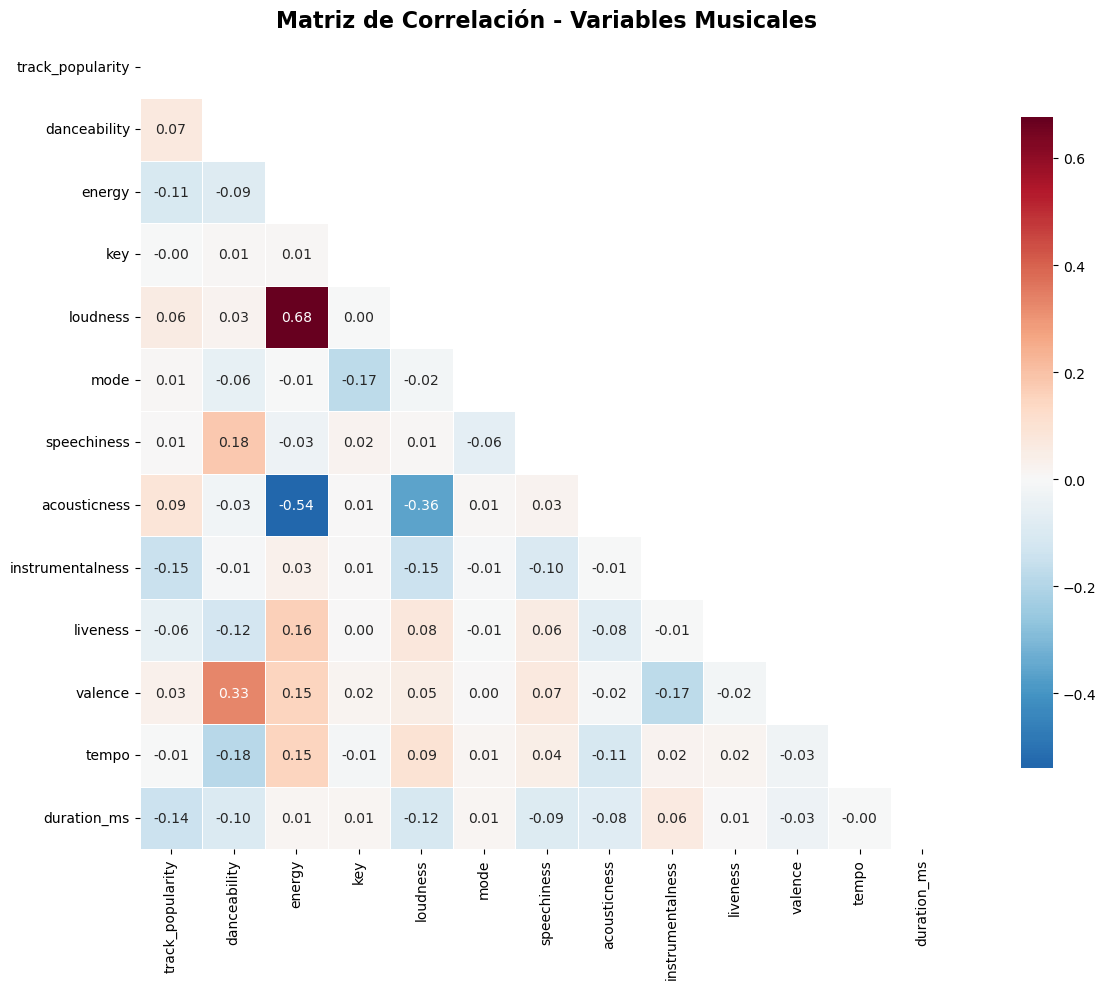

In [77]:

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(df_corr, dtype=bool))
sns.heatmap(df_corr, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Musicales', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

.

Una de las relaciones más fuertes se observa entre **energy y loudness (0.68)**. Esto es coherente desde el punto de vista musical, ya que las canciones con mayor energía suelen presentar niveles de volumen más altos. Esta correlación positiva indica que a medida que aumenta la energía de una canción, también tiende a aumentar su intensidad sonora.

Otra relación relevante aparece entre **energy y acousticness (-0.54)**. La correlación negativa sugiere que las canciones con alta energía tienden a tener **menor componente acústico**, lo cual es consistente con la producción musical moderna, donde los géneros más energéticos suelen depender más de instrumentos electrónicos y producción digital.

En el caso de la variable **track_popularity**, las correlaciones con las demás variables musicales son relativamente **bajas**. Por ejemplo, la relación con **danceability (0.07)** y **energy (-0.11)** es mu

 débil. Esto indica que la popularidad de una canción probablemente depende de **factores adicionales** que no están directamente reflejados en estas características musicales, como tendencias del mercado, promoción, artista o contexto cultural.

También se observa una correlación positiva moderada entre **danceability y valence (0.33)**, lo que sugiere que las canciones más bailables tienden a transmitir emociones más positivas o alegres.

En conjunto, los resultados muestran que aunque algunas características musicales están relacionadas entre sí, **la popularidad de las canciones no está fuertemente determinada por una sola variablcción musical.

In [80]:
print("\n" + "="*80)
print("🔍 TOP 3 CORRELACIONES MÁS FUERTES")
print("="*80)

# Obtener correlaciones únicas (sin duplicados ni diagonal)
corr_pares = []
for i in range(len(vars_existentes)):
    for j in range(i+1, len(vars_existentes)):
        var1 = vars_existentes[i]
        var2 = vars_existentes[j]
        corr_val = df_corr.iloc[i, j]
        if not np.isnan(corr_val):
            corr_pares.append((var1, var2, corr_val))

# Ordenar por valor absoluto de correlación
corr_pares.sort(key=lambda x: abs(x[2]), reverse=True)

# Mostrar top 3 positivas y negativas
print("\n📈 TOP 3 CORRELACIONES POSITIVAS:")
pos_count = 0
for var1, var2, val in corr_pares:
    if val > 0 and pos_count < 3:
        print(f"   {pos_count+1}. {var1} vs {var2}: {val:.3f}")
        pos_count += 1

print("\n📉 TOP 3 CORRELACIONES NEGATIVAS:")
neg_count = 0
for var1, var2, val in corr_pares:
    if val < 0 and neg_count < 3:
        print(f"   {neg_count+1}. {var1} vs {var2}: {val:.3f}")
        neg_count += 1

# Mostrar todas las correlaciones ordenadas (opcional)
print("\n📊 TODAS LAS CORRELACIONES (ordenadas por fuerza):")
for i, (var1, var2, val) in enumerate(corr_pares[:10], 1):
    tipo = "positiva" if val > 0 else "negativa"
    print(f"   {i:2}. {var1:15} vs {var2:15}: {val:6.3f} ({tipo})")


🔍 TOP 3 CORRELACIONES MÁS FUERTES

📈 TOP 3 CORRELACIONES POSITIVAS:
   1. energy vs loudness: 0.677
   2. danceability vs valence: 0.330
   3. danceability vs speechiness: 0.182

📉 TOP 3 CORRELACIONES NEGATIVAS:
   1. energy vs acousticness: -0.539
   2. loudness vs acousticness: -0.361
   3. danceability vs tempo: -0.184

📊 TODAS LAS CORRELACIONES (ordenadas por fuerza):
    1. energy          vs loudness       :  0.677 (positiva)
    2. energy          vs acousticness   : -0.539 (negativa)
    3. loudness        vs acousticness   : -0.361 (negativa)
    4. danceability    vs valence        :  0.330 (positiva)
    5. danceability    vs tempo          : -0.184 (negativa)
    6. danceability    vs speechiness    :  0.182 (positiva)
    7. instrumentalness vs valence        : -0.175 (negativa)
    8. key             vs mode           : -0.174 (negativa)
    9. energy          vs liveness       :  0.162 (positiva)
   10. energy          vs valence        :  0.152 (positiva)


**¿Qué significan en el contexto del problema?**

Las correlaciones más fuertes (**energy-loudness positiva, energy-acousticness negativa, loudness-acousticness negativa**) revelan una división fundamental en la música:

* Opción A: Alta energía, alto volumen, baja acústica (electrónico, rock, pop producido)

* Opción B: Baja energía, bajo volumen, alta acústica (baladas, folk, música de cantautor)

Esta separación refleja decisiones de producción y géneros musicales claramente diferenciados.

Danceability correlaciona positivamente con valence (alegría) y speechiness (contenido hablado), pero negativamente con tempo. Esto indica que la bailabilidad óptima no es simplemente velocidad, sino una combinación de:

* Ritmos moderados

* Carácter(Alegría)

* Presencia de elementos vocales/rapeados

**POR QUÉ CORRELACIÓN NO IMPLICA CAUSALIDAD**

La correlación indica que dos variables tienden a variar juntas, pero no demuestra que una sea la causa de la otra. Puede existir una tercera variable no considerada,que explique ambas o la relación podría ser inversa

Por ejemplo, en este dataset encontramos que**energy vs loudness** tienen una correlación positiva de 0.677, pero esto no significa que subir el volumen haga una canción más energética; en realidad, ambos son consecuencia del género musical (rock y EDM se producen con alta energía Y alto volumen por convención). 


## Conclusiones 

**Pregunta 1: ¿Existe una relación entre la energía de una canción y su nivel de popularidad?**

Los resultados mostraron que no hay una relación clara. Las canciones de energía media tienen la popularidad más alta (44.92), seguidas muy de cerca por las de baja energía (44.88), mientras que las de alta energía quedaron por debajo (41.01). Esto contradice la idea de que "más energía = más éxito". De hecho, las canciones de alta energía son las más abundantes en el dataset (20,451 canciones), pero las menos populares en promedioo.

**Pregunta 2: ¿Qué géneros musicales presentan en promedio mayores niveles de popularidad?**

El pop (47.75) y la música latina (47.02) lideran claramente. Les siguen rap (43.22), rock (41.71) y r&b (41.22). El EDM queda último con 34.85, a pesar de ser el género con más canciones (6,038). Esto confirma lo que se ve en las listas actuales: artistas como Taylor Swift, Bad Bunny o Karol G dominan el streaming.



**Pregunta 3: ¿Las canciones con mayor danceability tienden a tener mayor popularidad?**

Los resultados muestran que **sí existe una relación positiva entre la bailabilidad y la popularidad de las canciones**. A medida que aumenta la bailabilidad, también aumenta la popularidad promedio. Las canciones con alta bailabilidad presentan una popularidad promedio de 43.84, las de nivel medio 41.06 y las de baja bailabilidad 38.94.

Además, se observa que las canciones con baja bailabilidad alcanzan como máximo una popularidad de 83, mientras que las canciones más bailables pueden llegar hasta 100. Esto sugiere que las canciones diseñadas para bailar tienen más probabilidad de alcanzar niveles altos de popularidadset.

## Hipotesís

### ✅ Hipótesis: ¿Se confirmaron o refutaron?

| Hipótesis | Resultado | Evidencia |
|-----------|-----------|-----------|
| A mayor energía, mayor popularidad | ❌ Refutada | Energía alta: 41.01 vs Energía media: 44.92 |
| El pop y la música latina son los más populares | ✅ Confirmada | Pop: 47.75, Latino: 47.02 (superan al resto) |
| Mayor bailabilidad = mayor popularidad | ✅ Confirmada | Alta: 43.84 > Media: 41.06 > Baja: 38.94 |

## Limitaciones del analisis 

**Representatividad de la muestra:** El dataset puede estar sesgado hacia ciertos géneros o artistas. Por ejemplo, EDM tiene 6,038 canciones pero baja popularidad, lo que podría indicar que se incluyeron muchos artistas underground o canciones poco conocidas de ese género.
**
Datos faltante**s: Algunas variables como acousticness, instrumentalness y valence estaban como string y tuvieron que convertirse, lo que pudo introducir erroress.**

La popularidad es relat**ita. Una canción puede tener 100 de popularidad una semana y bajar al siguie
p**o.

Variables no conside**
* adas: No se incluyeron factores como el año de lanza
* Eal), el sello discog
* Si, o si la canción fue usada en viral de Txi  **to).

O**utliers: Variabl**es como instrume**ntalness tienen 21% de valores atípicos, lo que puede distorsionar algunos análisis.

## Propuestas de analísis futuros

**Modelo para predecir qué canciones pegan:** Con las variables que ya tenemos, se podría armar un modelo que intente adivinar si una canción va a ser popular o no. Algo así como un sistema que aprenda de los éxitos del pasado y diga "esta tiene pinta de hit".

**Analizar las letras:** Si además de los números tuviéramos las letras de las canciones, se podría ver de qué hablan las que son exitosas. ¿Hablan más de amor? ¿De fiesta? ¿De temas sociales? También se podría medir si las letras son positivas o negativas y ver si eso influye en la popularidad. Esto ya es más avanzado porque tocaría procesar texto.

**Un recomendador como el de Spotify:** Con los datos de qué características tienen las canciones, se podría armar un sistema que recomiende canciones parecidas. Algo tipo "te gusta esta canción, entonces te van a gustar estas otras que suenan parecido". No es exactamente lo mismo que el descubrimiento semanal de Spotify pero se parece.